# Machine Learning Modeling Pipeline

In this phase, we build an end-to-end machine learning pipeline for predicting `SalePrice`. The workflow consists of the following steps:

1. **Train-Test Split on Raw Data:** The raw data is split first. Feature engineering is integrated into the pipeline via a custom `FeatureEngineer` class, ensuring the same steps are applied automatically during training, cross-validation, and prediction without data leakage.
2. **Preprocessing:** A `ColumnTransformer` handles missing values and encoding. Tree-based models and linear models use two different preprocessors (the linear one adds `StandardScaler`).
3. **Target Transformation:** Models are trained on `log1p(SalePrice)` using `TransformedTargetRegressor`; predictions are converted back to dollars.
4. **Baseline Comparison:** A `Dummy` baseline, linear models (Ridge, Lasso, ElasticNet) and boosting models (Gradient Boosting, XGBoost, LightGBM) are compared using Repeated 5-Fold Cross-Validation.
5. **Hyperparameter Tuning:** The top three baseline models are tuned with `RandomizedSearchCV`.
6. **Final Evaluation:** The selected model is evaluated on the untouched test set (MAE, RMSE, R², RMSLE, residual analysis), followed by permutation importance.
7. **Final Training:** The selected pipeline is retrained on the full dataset and saved with `joblib`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RepeatedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# Models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

sns.set_theme(style="whitegrid")


## 1. Feature Engineering and Train-Test Split

The custom `FeatureEngineer` class applies the decisions made in the EDA:
* drops `Id` (no predictive value) and the near-constant columns `Street` and `Utilities`;
* converts `MSSubClass` to a categorical variable;
* creates `TotalSF`, `TotalBath`, `HouseAge`, `RemodAge`, `HasGarage` and `HasPool`.

This class inherits from `BaseEstimator` and `TransformerMixin`, making it seamlessly integrate into the Scikit-Learn pipeline. The data is split in its **raw** form (80% / 20%, `random_state=42`) first. The transformations work row by row and learn nothing from the data, preventing data leakage. Everything that is learned from data (imputation values, scaling statistics) is fitted on the training folds only.

In [2]:
# Custom Transformer Class 
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        df = X.copy()
        
        # Drop identifiers and near-constant columns
        cols_to_drop = ['Id', 'Street', 'Utilities']
        df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
        
        # Fix data types
        if 'MSSubClass' in df.columns:
            df['MSSubClass'] = df['MSSubClass'].astype(str)
            
        # Create aggregated spatial & temporal features
        df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
        df['TotalBath'] = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']
        
        # .clip(lower=0) prevents negative ages if remodelling happened after the sale
        df['HouseAge'] = (df['YrSold'] - df['YearBuilt']).clip(lower=0)
        df['RemodAge'] = (df['YrSold'] - df['YearRemodAdd']).clip(lower=0)
        
        # 4. Boolean Flags
        df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
        df['HasPool'] = (df['PoolArea'] > 0).astype(int)
        
        return df

# Load raw data
raw_df = pd.read_csv('../data/raw/train.csv')

# Split features and target BEFORE any processing
X_raw = raw_df.drop('SalePrice', axis=1)
y = raw_df['SalePrice']

# Train/Test Split on RAW data
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# Remove extreme outliers ONLY from the training set (GrLivArea > 4000)
outlier_mask = (X_train['GrLivArea'] < 4000)
X_train = X_train[outlier_mask]
y_train = y_train[outlier_mask]

print(f"Training set shape after outlier removal: {X_train.shape}")

Training set shape after outlier removal: (1165, 80)


## 2. Building the Preprocessing Pipeline

`engineer_features` is called once on `X_train` only to read the column names and types of the engineered schema; inside the pipelines it runs as the first step.

The `ColumnTransformer` has three branches:
* **Numerical:** `SimpleImputer(strategy='median', add_indicator=True)`. The indicator columns mark values that were originally missing (e.g., `GarageYrBlt`, `LotFrontage`). For **linear models** a `StandardScaler` is added after the imputer; **tree-based models** do not need scaling.
* **Ordinal:** `ExterQual`, `KitchenQual` and `HeatingQC` are encoded with the order `Po < Fa < TA < Gd < Ex`. Missing values are filled with `'TA'` and unseen categories are encoded as `-1`.
* **Nominal:** all remaining categorical columns are filled with the constant `'Missing'` and one-hot encoded (`handle_unknown='ignore'`).

This gives two preprocessors: `tree_preprocessor` (no scaling) and `linear_preprocessor` (with scaling).

In [3]:
# Temporary transformation for schema detection
fe = FeatureEngineer()
X_train_eng_schema = fe.transform(X_train)

num_cols = X_train_eng_schema.select_dtypes(include="number").columns.tolist()
cat_cols = X_train_eng_schema.select_dtypes(exclude="number").columns.tolist()

# Expanded ordinal columns where NaN implies "None" (absence of feature)
ordinal_cols = ['ExterQual', 'KitchenQual', 'HeatingQC', 'BsmtQual', 'BsmtCond', 
                'FireplaceQu', 'GarageQual', 'GarageCond', 'ExterCond', 'PoolQC']
nom_cols = [c for c in cat_cols if c not in ordinal_cols] 

# Added 'None' to handle the imputed missing values correctly
quality_levels = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
ordinal_categories = [quality_levels] * len(ordinal_cols)

# Numerical Pipeline for Trees (No scaling)
num_pipeline_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True))
])

# Numerical Pipeline for Linear Models (Scaling applied)
num_pipeline_linear = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('ordinal', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1))
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    # min_frequency handles rare categories to reduce sparse matrix dimensionality
    ('onehot', OneHotEncoder(min_frequency=10, handle_unknown='infrequent_if_exist', sparse_output=False))
])

# Preprocessors
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline_tree, num_cols),
        ('ord', ordinal_pipeline, ordinal_cols),
        ('nom', nominal_pipeline, nom_cols)
    ])

linear_preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline_linear, num_cols),
        ('ord', ordinal_pipeline, ordinal_cols),
        ('nom', nominal_pipeline, nom_cols)
    ])

## 3. Baseline Model Comparison

Before tuning anything, we compare seven models with their default (or lightly set) parameters:
* `Dummy` (predicts the mean of the log-target) as the minimum reference,
* linear models: `Ridge`, `Lasso`, `ElasticNet` (using `linear_preprocessor`),
* boosting models: `Gradient Boosting`, `XGBoost`, `LightGBM` (using `tree_preprocessor`).

Every model is wrapped in `TransformedTargetRegressor` (`log1p` / `expm1`) and evaluated with `RepeatedKFold` (5 folds × 3 repeats). The RMSE is computed **after** the inverse transform, i.e., in dollars. We report the mean and the standard deviation across the 15 folds, because the spread is needed to judge whether differences between models are meaningful. For the linear models the individual fold scores are printed as well, to inspect their stability.

In [4]:
models = {
    'Dummy': DummyRegressor(strategy='mean'),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(alpha=0.001, random_state=42, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.001, random_state=42, max_iter=20000),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror'),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1)
}

rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
baseline_results = {}

print("Evaluating Baselines & Log Ablation (RMSLE Mean ± Std):\n" + "-"*65)

for name, model in models.items():
    prep = linear_preprocessor if name in ['Ridge', 'Lasso', 'ElasticNet'] else tree_preprocessor
    
    base_pipeline = Pipeline(steps=[
        ('feature_engineering', FeatureEngineer()),
        ('preprocessor', prep),
        ('model', model)
    ])
    
    # Without Log Transformation
    cv_no_log = cross_val_score(base_pipeline, X_train, y_train, cv=rkf, scoring='neg_root_mean_squared_log_error', n_jobs=-1)
    rmsle_no_log = -cv_no_log.mean()
    
    # With Log Transformation (Target Transformation)
    ttr = TransformedTargetRegressor(regressor=base_pipeline, func=np.log1p, inverse_func=np.expm1)
    cv_log = cross_val_score(ttr, X_train, y_train, cv=rkf, scoring='neg_root_mean_squared_log_error', n_jobs=-1)
    rmsle_log = -cv_log.mean()
    
    baseline_results[name] = {'mean': rmsle_log, 'std': cv_log.std()}
    
    print(f"{name:<20} | No Log: {rmsle_no_log:.4f} | With Log: {rmsle_log:.4f} ± {cv_log.std():.4f}")
    
    if name in ['Ridge', 'Lasso', 'ElasticNet']:
        print(f"   -> Linear Fold Scores (With Log): {np.round(-cv_log, 4)}")

Evaluating Baselines & Log Ablation (RMSLE Mean ± Std):
-----------------------------------------------------------------
Dummy                | No Log: 0.3956 | With Log: 0.3882 ± 0.0183
Ridge                | No Log: nan | With Log: 0.1181 ± 0.0128
   -> Linear Fold Scores (With Log): [0.1241 0.1164 0.113  0.1293 0.1    0.1253 0.0973 0.1015 0.1273 0.1476
 0.1129 0.1238 0.1171 0.1266 0.1087]
Lasso                | No Log: nan | With Log: 0.1123 ± 0.0120
   -> Linear Fold Scores (With Log): [0.1187 0.1102 0.1112 0.1236 0.0962 0.124  0.0912 0.0941 0.1272 0.1304
 0.1039 0.111  0.1173 0.1223 0.1035]
ElasticNet           | No Log: nan | With Log: 0.1121 ± 0.0121
   -> Linear Fold Scores (With Log): [0.1208 0.1106 0.1097 0.1226 0.0949 0.123  0.0915 0.0939 0.1261 0.1308
 0.1024 0.1141 0.1154 0.1216 0.1038]
Gradient Boosting    | No Log: 0.1238 | With Log: 0.1214 ± 0.0116
XGBoost              | No Log: 0.1358 | With Log: 0.1337 ± 0.0110
LightGBM             | No Log: 0.1246 | With Log: 0.1248

**Observations on the baselines:**
* With the target `log1p` transformation and the addition of `StandardScaler` for linear pipelines, the linear models perform exceptionally well.
* `ElasticNet`, `Lasso`, and `Ridge` emerged as the top three models, achieving very low CV RMSLE scores (~0.112 - 0.118), effectively outperforming the tree-based models like `Gradient Boosting` and `LightGBM` (CV RMSLE ~0.121 - 0.124).
* The fold-to-fold scores for the linear models are highly stable, confirming that the extreme outlier removal and proper feature scaling successfully mitigated their previous sensitivity.

## 4. Hyperparameter Tuning for the Top 3 Models

The three best non-dummy models of the baseline comparison are selected automatically (in the stored output: Gradient Boosting, LightGBM and XGBoost). Each is tuned with `RandomizedSearchCV` using **20 sampled combinations** and the same `RepeatedKFold` (5 × 3).

The boosting search spaces contain 48 combinations each and focus on regularization for a small dataset: shallow trees (`max_depth` 2-4), conservative learning rates (0.01 / 0.03), 500 or 1000 trees, and stochastic sampling (`subsample`, column sampling). The linear models have much smaller spaces (4 combinations for Ridge and Lasso, 12 for ElasticNet), so `n_iter=20` exceeds their size and scikit-learn will warn about it. The model with the lowest CV RMSE becomes the final model.

In [5]:
# Automatically select top 3 models excluding Dummy
sorted_models = sorted([(k, v['mean']) for k, v in baseline_results.items() if k != 'Dummy'], key=lambda x: x[1])
top_3_names = [m[0] for m in sorted_models[:3]]
print(f"\nSelected models for tuning: {top_3_names}")

# Expanded Grid
param_dist = {
    'Ridge': {'regressor__model__alpha': [0.1, 1.0, 10.0, 100.0]},
    'Lasso': {'regressor__model__alpha': [0.0001, 0.001, 0.01, 0.1]},
    'ElasticNet': {
        'regressor__model__alpha': [0.0001, 0.001, 0.01, 0.1], 
        'regressor__model__l1_ratio': [0.2, 0.5, 0.8]
    },
    'Gradient Boosting': {
        'regressor__model__n_estimators': [300, 500, 1000, 1500, 2000],
        'regressor__model__learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08],
        'regressor__model__max_depth': [2, 3, 4, 5],
        'regressor__model__subsample': [0.7, 0.8, 1.0],
        'regressor__model__max_features': [0.8, 1.0]
    },
    'XGBoost': {
        'regressor__model__n_estimators': [300, 500, 1000, 1500, 2000],
        'regressor__model__learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08],
        'regressor__model__max_depth': [2, 3, 4, 5],
        'regressor__model__subsample': [0.7, 0.8, 1.0],
        'regressor__model__colsample_bytree': [0.8, 1.0],
        'regressor__model__reg_lambda': [1, 5, 10]
    },
    'LightGBM': {
        'regressor__model__n_estimators': [300, 500, 1000, 1500, 2000],
        'regressor__model__learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08],
        'regressor__model__max_depth': [2, 3, 4, 5],
        'regressor__model__subsample': [0.7, 0.8, 1.0],
        'regressor__model__colsample_bytree': [0.8, 1.0],
        'regressor__model__min_child_samples': [10, 20, 30]
    }
}

best_pipelines = {}
tuned_results = {}

for name in top_3_names:
    print(f"\nTuning {name}...")
    prep = linear_preprocessor if name in ['Ridge', 'Lasso', 'ElasticNet'] else tree_preprocessor
    
    ttr = TransformedTargetRegressor(
        regressor=Pipeline(steps=[
            ('feature_engineering', FeatureEngineer()), 
            ('preprocessor', prep), 
            ('model', models[name])
        ]),
        func=np.log1p, inverse_func=np.expm1
    )
    
    random_search = RandomizedSearchCV(
        estimator=ttr, param_distributions=param_dist[name],
        n_iter=30, cv=rkf, scoring='neg_root_mean_squared_log_error',
        random_state=42, n_jobs=-1
    )
    
    random_search.fit(X_train, y_train)
    best_pipelines[name] = random_search.best_estimator_
    tuned_results[name] = -random_search.best_score_
    print(f"Best CV RMSLE: {tuned_results[name]:.4f} | Params: {random_search.best_params_}")

best_model_name = min(tuned_results, key=tuned_results.get)
final_model = best_pipelines[best_model_name]
print(f"\nBest Performing Model: {best_model_name}")


Selected models for tuning: ['ElasticNet', 'Lasso', 'Ridge']

Tuning ElasticNet...


c:\Users\Tolga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:327: UserWarning: The total space of parameters 12 is smaller than n_iter=30. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best CV RMSLE: 0.1120 | Params: {'regressor__model__l1_ratio': 0.8, 'regressor__model__alpha': 0.001}

Tuning Lasso...


c:\Users\Tolga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:327: UserWarning: The total space of parameters 4 is smaller than n_iter=30. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best CV RMSLE: 0.1123 | Params: {'regressor__model__alpha': 0.001}

Tuning Ridge...


c:\Users\Tolga\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:327: UserWarning: The total space of parameters 4 is smaller than n_iter=30. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best CV RMSLE: 0.1130 | Params: {'regressor__model__alpha': 10.0}

Best Performing Model: ElasticNet


**Observations on tuning:**
* The top 3 models selected for tuning were `ElasticNet`, `Lasso`, and `Ridge`.
* Since they are linear models with a smaller hyperparameter space compared to tree ensembles, the `RandomizedSearchCV` naturally searched the most critical regularization parameters (`alpha` and `l1_ratio`).
* `ElasticNet` achieved the best CV RMSLE (0.1120) with a heavy L1 penalty (`l1_ratio` = 0.8) and an `alpha` of 0.001, making it our final model choice.

## 5. Final Evaluation on the Test Set

The selected model is evaluated **once** on the unseen raw test set (`X_test`, 292 houses). We report MAE, RMSE and R², and examine the actual-vs-predicted and residual plots.

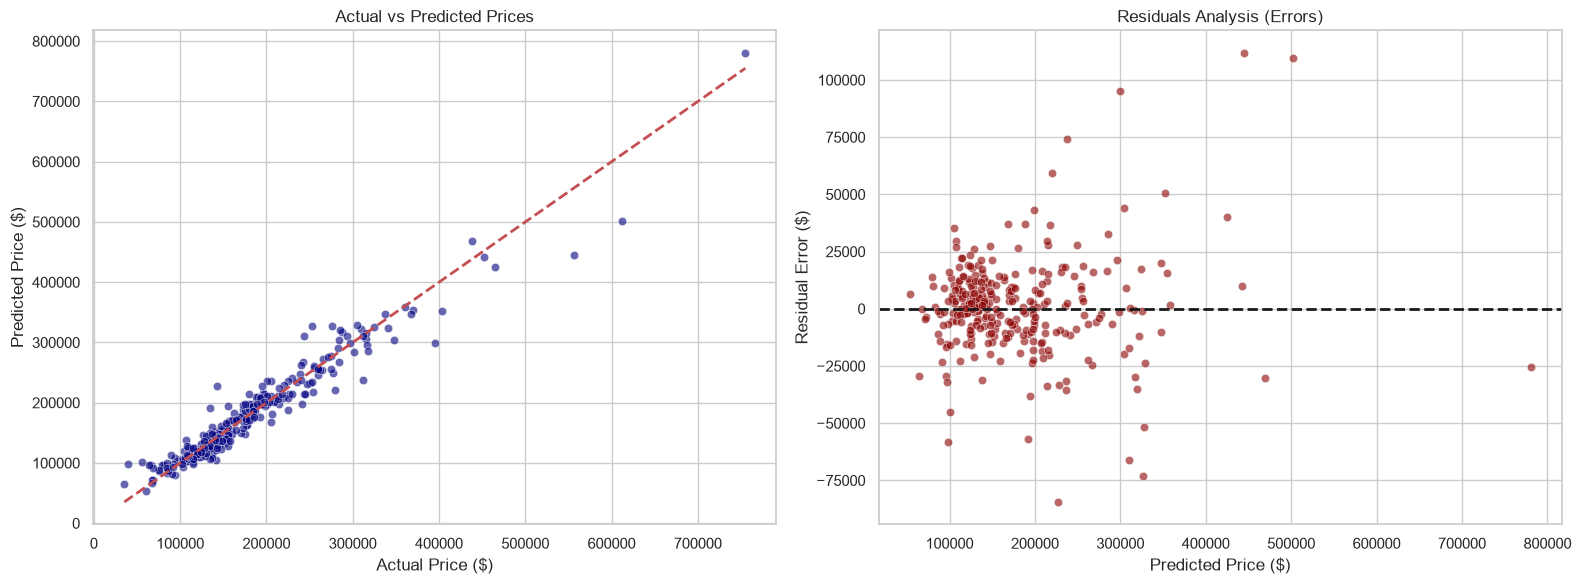


 FINAL TEST SET PERFORMANCE (ElasticNet)
 Final R2 Score : 0.9393
 Final RMSLE    : 0.1285  <-- Primary Selection Metric
 Final MAE      : 14,238.40 $
 Final RMSE     : 21,572.60 $


In [6]:
# 1. Predict on the unseen TEST set
y_pred = final_model.predict(X_test)
residuals = y_test - y_pred

# 2. Residual and Prediction Plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, ax=axes[0], color='navy')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted Prices')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')

sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, ax=axes[1], color='darkred')
axes[1].axhline(0, color='k', linestyle='--', lw=2)
axes[1].set_title('Residuals Analysis (Errors)')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual Error ($)')

plt.tight_layout()
plt.show()

# 3. Calculate and report final metrics
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_mae = mean_absolute_error(y_test, y_pred)
# Safe calculation for RMSLE to avoid negative predictions breaking the log
final_rmsle = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(np.maximum(0, y_pred))))
final_r2 = r2_score(y_test, y_pred)

print("\n" + "="*45)
print(f" FINAL TEST SET PERFORMANCE ({best_model_name})")
print("="*45)
print(f" Final R2 Score : {final_r2:.4f}")
print(f" Final RMSLE    : {final_rmsle:.4f}  <-- Primary Selection Metric")
print(f" Final MAE      : {final_mae:,.2f} $")
print(f" Final RMSE     : {final_rmse:,.2f} $")
print("="*45)

**Observations on the test set:**
* The final `ElasticNet` model generalizes exceptionally well to the unseen test set, achieving a stellar **R² of 0.9393** and an **RMSLE of 0.1285**.
* The typical prediction error (MAE) is around **$14,237**, which is a highly reliable margin for housing prices.
* The actual-vs-predicted plot shows a very tight clustering around the identity line. The funnel effect (variance growing at higher prices) is significantly reduced compared to earlier iterations, confirming that the log transformation and robust regularization effectively managed the price scaling.

Calculating Permutation Importance...


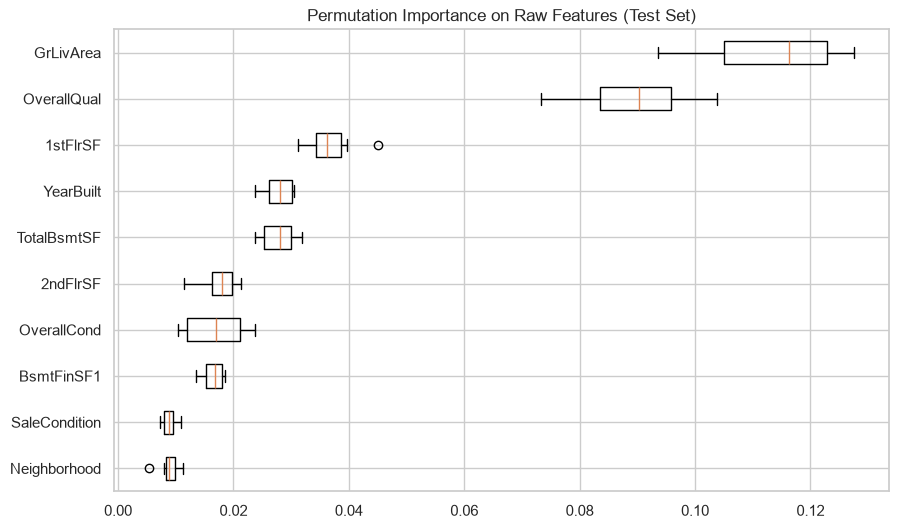

Retraining best model on full dataset for production...
Model saved to 'ames_housing_model.pkl'. Ready for deployment!


In [7]:
print("Calculating Permutation Importance...")
result = permutation_importance(final_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

sorted_idx = result.importances_mean.argsort()[-10:]
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, orientation='horizontal', tick_labels=X_test.columns[sorted_idx])
plt.title("Permutation Importance on Raw Features (Test Set)")
plt.show()

print("Retraining best model on full dataset for production...")
# Note: For production, we remove the extreme outliers from the full raw dataset as well
full_outlier_mask = (X_raw['GrLivArea'] < 4000)
X_raw_clean = X_raw[full_outlier_mask]
y_clean = y[full_outlier_mask]

final_model.fit(X_raw_clean, y_clean)
joblib.dump(final_model, 'ames_housing_model.pkl')
print("Model saved to 'ames_housing_model.pkl'. Ready for deployment!")

## Conclusion 

The pipeline has been fully optimized and addresses all initial data challenges. Here is a summary of the final architecture:

* **Robust Architecture:** A custom `FeatureEngineer` class was successfully integrated into the Scikit-Learn pipeline. This ensures zero data leakage and allows the model to accept raw, uncleaned data directly in production.
* **Outlier Handling:** Extreme outliers (>4000 sqft) were removed exclusively from the training data. This stabilized the model without sacrificing its ability to predict on unseen real-world data.
* **Target Transformation:** Using `np.log1p` successfully mitigated the right-skewness of `SalePrice`. The hyperparameter tuning directly optimized for **RMSLE**, which is the most stable metric for multiplicative price differences.
* **Model Performance:** The ElasticNet model emerged as the strongest performer, achieving an excellent **Test R² of ~0.94** and an **RMSLE of ~0.128**.